### NBA Game Log Data Structure
The dataset follows a **Document-per-Game** model. Each record captures the performance of a player.

**Data Management Challenges:**
* **Sparse Fields:** Rows marked as `Inactive` or `Did Not Dress` contain no statistical data. They are like placeholders for the team's schedule.
* The final row of the CSV contains aggregated season totals (e.g., `1956` points), which must be filtered out to avoid skewing per-game averages.
* The `MP` (Minutes Played) field is stored as a string (`MM:SS`), we need transformation for numerical analysis.
* **Schema Flexibility:** While most fields are numeric, MongoDB's ability to store these alongside string-based status updates (Inactive) demonstrates why a NoSQL approach is superior to a rigid SQL schema for raw game logs.

## MongoDB Setup

In [1]:
import sys
!{sys.executable} -m pip install pymongo
!{sys.executable} -m pip install dnspython
!{sys.executable} -m pip install certifi

## 1.1 Data Ingestion & Managed Database Setup
In this cell we initialise the connection to the local **MongoDB** instance and creates the `player_games` collection. 

* **Resetting the Environment:** 
* **Ingestion:** Scan local directory for NBA game log CSVs
* Extract  player's name from the filename and injects it into every document as a relational key.
* Converts Pandas DataFrames into BSON-compatible dictionaries for bulk insertion into the NoSQL database.

Since MongoDB is schemaless, it is important to verify the BSON structure of our ingested documents. This ensures all fields from the CSV (like GmSc, PTS, and BLK) were mapped correctly to the NoSQL collection.

In [2]:
import pandas as pd
import os
from pymongo import MongoClient
from pprint import pprint

# 1. Connecting to Mongo
client = MongoClient("mongodb://localhost:27017/")
db = client["NBA_Project"]
collection = db["player_games"]

# 2. clean start
collection.delete_many({}) 

# convert "MM:SS" to decimal minutes
def convert_minutes(mp):
    if isinstance(mp, str) and ":" in mp:
        try:
            m, s = mp.split(":")
            return int(m) + int(s)/60
        except:
            return None # Use None (null) for invalid time data
    return None

# 3. INGESTION: Load, Clean, and Typecast
folder_path = "./"
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

numeric_cols = ["PTS", "AST", "BLK", "STL", "TRB", "ORB", "DRB", "TOV", "PF", "GmSc"]

for file in csv_files:
    player_name = os.path.splitext(file)[0].split("_")[0]
    df = pd.read_csv(file)
    df['Player'] = player_name
    # remove "Unnamed" junk columns (CSV noise)
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    # "Inactive" or "DNP" to NaN (null) (to ignore during any calculation)
    # This prevents skewing averages.
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    # time conversion
    if "MP" in df.columns:
        df["MP"] = df["MP"].apply(convert_minutes)
    # Convert to dictionary
    records = df.to_dict(orient='records')
    
    if records:
        # batch insert with ordered=False for performance (insert even if one row has an error)
        collection.insert_many(records, ordered=False)
        print(f"-> Ingested {len(records)} cleaned records for: {player_name}")

# create only essential compound index
collection.create_index([("Player", 1), ("Date", -1)]) #name in asc, dates in desc (newest to oldest)
print("\n🚀 Database Optimized: Compound Index (Player, Date) created.")

print("-" * 30)
sample = collection.find_one({"Player": "JarenJr", "PTS": {"$ne": None}})
print("Document Structure")
pprint(sample)

-> Ingested 83 cleaned records for: Giannis
-> Ingested 83 cleaned records for: Luca
-> Ingested 83 cleaned records for: Anthony
-> Ingested 83 cleaned records for: Stephen
-> Ingested 83 cleaned records for: JarenJr
-> Ingested 83 cleaned records for: Rudy
-> Ingested 83 cleaned records for: Jusuf
-> Ingested 83 cleaned records for: Lebron
-> Ingested 83 cleaned records for: Jayson
-> Ingested 83 cleaned records for: Domantas
-> Ingested 83 cleaned records for: Chet
-> Ingested 83 cleaned records for: Victor

🚀 Database Optimized: Compound Index (Player, Date) created.
------------------------------
Document Structure
{'+/-': '-1',
 '2P': '2',
 '2P%': '.500',
 '2PA': '4',
 '3P': '0',
 '3P%': '.000',
 '3PA': '5',
 'AST': 3.0,
 'BLK': 5.0,
 'DRB': 4.0,
 'Date': '2023-10-25',
 'FG': '2',
 'FG%': '.222',
 'FGA': '9',
 'FT': '4',
 'FT%': '1.000',
 'FTA': '4',
 'GS': '*',
 'Gcar': 268.0,
 'GmSc': 5.0,
 'Gtm': 1.0,
 'MP': 35.71666666666667,
 'ORB': 1.0,
 'Opp': 'NOP',
 'PF': 5.0,
 'PTS': 8.0

## 1.2 Technical Advantage: Dynamic Schema & Evolution
A core requirement for this project was the ability to handle **unstructured data**. 

**The SQL Problem:** In a Relational Database (RDBMS), adding a new metric like "Defensive Rating" requires a database-wide schema migration, which causes downtime and rigid data constraints.

**The MongoDB Solution:** As demonstrated in the code below, we successfully ingested an "Advanced Tracking" document for Jaren Jackson Jr. that contains nested fields (`Advanced_Stats`) not present in other player records. 

* **Zero Downtime:** We added new data types without restructuring the database.
* **Nested Objects** 

In [3]:
# Advanced Metrics
# simulating an 'Advanced Tracking' data source for JJJ 
# this is a field other players don't have (like Defensive_Rating)
advanced_entry = {
    "Player": "JarenJr",
    "Date": "2024-04-10",
    "PTS": 25,
    "Advanced_Stats": {
        "Defensive_Rating": 102.5,
        "Contested_Shots": 14,
        "Distance_Traveled_Miles": 2.8
    },
    "Source": "Second-Spectrum-Tracking"
}
collection.insert_one(advanced_entry)
jjj_adv = collection.find_one({"Advanced_Stats.Defensive_Rating": {"$exists": True}})
print(f"Flexible Ingestion!")
print(f"New Metric Found for \n {jjj_adv['Player']}: {jjj_adv['Advanced_Stats']}")

Flexible Ingestion!
New Metric Found for 
 JarenJr: {'Defensive_Rating': 102.5, 'Contested_Shots': 14, 'Distance_Traveled_Miles': 2.8}


## 2. Database Optimization: Multi-Level Indexing & System Audit
Before executing complex analytical queries, we implement both **Single-Field** and **Compound Indexes** on our most queried attributes. 

* **Compound Index (Player, Date):** Optimizes queries that filter by player and sort by game date simultaneously.
* **Storage Analysis:** Using the `collstats` command to monitor index overhead and storage efficiency.
* **Query Acceleration:** Prevents expensive `COLLSCAN` operations by providing a B-Tree lookup structure.

In [4]:
# creating indexes for fast lookup
# indexing Player field asc
collection.create_index([("Player", 1)])
collection.create_index([("PTS", 1)])
print(f"Current Indexes: {list(collection.index_information().keys())}")
# Compound Index on Player and Date
# Helpful to load graphs instantly even with a  lot of games
collection.create_index([("Player", 1), ("Date", -1)])
print("Compound Index created for (Player, Date).")
db_stats = db.command("collstats", "player_games")
print(f"Database Storage Size: {db_stats['size'] / 1024:.2f} KB")
print(f"Total Index Size: {db_stats['totalIndexSize'] / 1024:.2f} KB")

Current Indexes: ['_id_', 'Player_1_Date_-1', 'Player_1', 'PTS_1']
Compound Index created for (Player, Date).
Database Storage Size: 457.50 KB
Total Index Size: 180.00 KB


### **Section 2.1 — Performance Audit**

Running `.explain()` command on a standard player query to verify effecttiveness:

* `IXSCAN` (Index Scan) - confirms the database is utilizing the B-Tree index rather than performing a costly `COLLSCAN` (Collection Scan).
* **Efficiency Ratio:** * `totalDocsExamined`: 84
    * `nReturned`: 84
    * **Ratio:** 1:1. 
* A 1:1 ratio indicates a efficient index usage. The database engine located the specific records for Jaren Jackson Jr. with zero "noise" or wasted CPU cycles.

In a production scouting system with millions of game logs, an $O(N)$ collection scan would lead to high latency. By implementing a **Compound Index** on `(Player, Date)`, we ensure $O(\log N)$ lookup keeping the application responsive as the dataset grows.

In [5]:
# 2.1 Checkingif index is working
# PyMongo, .explain() -> full dictionary
explain_output = collection.find({"Player": "JarenJr"}).explain()
pprint(explain_output['queryPlanner']['winningPlan'])
print("\nExecution Statistics")
pprint(explain_output['executionStats'])

{'inputStage': {'direction': 'forward',
                'indexBounds': {'Player': ['["JarenJr", "JarenJr"]']},
                'indexName': 'Player_1',
                'indexVersion': 2,
                'isMultiKey': False,
                'isPartial': False,
                'isSparse': False,
                'isUnique': False,
                'keyPattern': {'Player': 1},
                'multiKeyPaths': {'Player': []},
                'stage': 'IXSCAN'},
 'isCached': False,
 'stage': 'FETCH'}

Execution Statistics
{'allPlansExecution': [{'executionStages': {'advanced': 84,
                                            'alreadyHasObj': 0,
                                            'docsExamined': 84,
                                            'executionTimeMillisEstimate': 0,
                                            'inputStage': {'advanced': 84,
                                                           'direction': 'forward',
                                                       

## 3. Advanced Analytics: Server-Side Aggregation Pipeline
Multi-stage **MongoDB Aggregation Pipeline** to perform data cleaning and statistical analysis directly on the database engine:

**Pipeline Stages:**
1. **\\$match:** Filters for documents containing valid performance metrics
2. **\\$project & \\$convert:** Dynamically casts string-based statistics (like "PTS") into doubles while handling "Inactive" or "DNP" entries
3. **Outlier Filtering:** Removes "Season Total" rows by filtering for individual game scores 
4. **\\$group:** Calculates **Population Standard Deviation** (`$stdDevPop`) to find player **Consistency**
5. **\\$sort:** Ranks players from most reliable (lowest deviation) to most volatile

In [6]:
# 3. Reliability 
pipeline_3 = [
    # 1. Taking Ooly games with actual points (not including DNPs/Totals)
    { "$match": { "PTS": { "$gt": 0, "$lt": 100 } } },
    # 2. group
    {
        "$group": {
            "_id": "$Player",
            "avg_points": { "$avg": "$PTS" },
            "std_dev": { "$stdDevPop": "$PTS" },
            "games": { "$count": {} }
        }
    },
    { "$sort": { "std_dev": 1 } }
]
results = list(collection.aggregate(pipeline_3))
print(f"{'PLAYER':<12} | {'GAMES':<6} | {'AVG PTS':<8} | {'CONSISTENCY'}")
print("-" * 55)
for r in results:
    print(f"{r['_id']:<12} | {r['games']:<6} | {r['avg_points']:<8.2f} | {r['std_dev']:.2f}")

PLAYER       | GAMES  | AVG PTS  | CONSISTENCY
-------------------------------------------------------
Rudy         | 76     | 13.96    | 5.15
Jusuf        | 76     | 10.91    | 6.03
Domantas     | 82     | 19.43    | 6.30
Chet         | 82     | 16.55    | 6.57
Lebron       | 71     | 25.66    | 6.61
Jayson       | 74     | 26.85    | 7.00
Victor       | 71     | 21.44    | 7.20
Anthony      | 76     | 24.68    | 8.00
JarenJr      | 67     | 22.55    | 8.37
Luca         | 70     | 33.86    | 8.75
Giannis      | 73     | 30.44    | 9.06
Stephen      | 74     | 26.43    | 9.52


## 4.1 The "Two-Way" Impact Analysis
This stage calculates the **Offensive Load** vs. **Defensive Activity**. 

* **Type Casting:** Uses `\\$convert` to transform raw string data into queryable numeric types
* **Feature Engineering:** Creates a metric `Defensive_Actions` by summing Blocks and Steals 
* By comparing `Avg_Points` against `Defensive_Actions`, we can see why a Relational DB might favor a defensive specialist (JJJ) while a more flexible analysis highlights offensive engines (Luka/Giannis).

In [7]:
# 4.1 Two-Way Analysis
superstar_pipeline = [
    { "$match": { "PTS": { "$gt": 0, "$lt": 100 } } },
    {
        "$group": {
            "_id": "$Player",
            "Avg_Points": { "$avg": "$PTS" },
            "Defensive_Actions":{"$avg":{"$add":["$BLK", "$STL"]}},
            "Peak_Game": { "$max": "$PTS" },
            "Avg_Efficiency": { "$avg": "$GmSc" }
        }
    },
    { "$sort": { "Avg_Points": -1 } }
]
superstar_results = list(collection.aggregate(superstar_pipeline))
print(f"{'PLAYER':<12} | {'AVG PTS':<8} | {'DEF_ACT':<8} | {'PEAK':<6} | {'EFFICIENCY'}")
print("-" * 60)
for s in superstar_results:
    print(f"{s['_id']:<12} | {s['Avg_Points']:<8.1f} | {s['Defensive_Actions']:.2f} | {s['Peak_Game']:<6.0f} | {s['Avg_Efficiency']:.2f}")

PLAYER       | AVG PTS  | DEF_ACT  | PEAK   | EFFICIENCY
------------------------------------------------------------
Luca         | 33.9     | 1.96 | 73     | 28.07
Giannis      | 30.4     | 2.27 | 64     | 26.90
Jayson       | 26.9     | 1.59 | 45     | 20.88
Stephen      | 26.4     | 1.11 | 60     | 18.79
Lebron       | 25.7     | 1.79 | 40     | 22.52
Anthony      | 24.7     | 3.54 | 41     | 23.43
JarenJr      | 22.6     | 2.82 | 44     | 15.13
Victor       | 21.4     | 4.82 | 40     | 18.44
Domantas     | 19.4     | 1.49 | 37     | 20.85
Chet         | 16.5     | 2.96 | 36     | 15.02
Rudy         | 14.0     | 2.82 | 26     | 15.39
Jusuf        | 10.9     | 2.12 | 31     | 11.74


### 4.2 Server-Side Feature Engineering
While raw totals (Points/Rebounds) provide a surface-level view, we utilize a **multi-stage MongoDB Aggregation Pipeline** to find "Efficiency" metrics that do not exist in the raw CSV data.

* We use `$addFields` and `$divide` to calculate **Points Per Minute (PPM)**
* **Computational Offloading:** By performing these calculations on the **Database Server** rather than in Python, we significantly reduce network latency and memory overhead
* We create a `Total_Offensive_Impact` score by summing fields (Points + Assists) directly in pipeline

In a traditional relational setup, creating these calculated virtual fields across a big dataset often requires complex Views or expensive sub-queries. MongoDB handles this within the aggregation pipeline, allowing Real-Time Analytics as new data is ingested.

In [8]:
# 4.2 EFFICIENCY: Points Per Minute (PPM)
efficiency_pipeline = [
    # Filter to avoid outliers
    { "$match": { "MP": { "$gt": 5 } } },
    {
        "$project": {
            "Player": 1,
            "Efficiency_Rating": { "$divide": ["$PTS", "$MP"] },
            "Impact_Score": { "$add": ["$PTS", "$AST"] }
        }
    },
    {
        "$group": {
            "_id": "$Player",
            "Avg_PPM": { "$avg": "$Efficiency_Rating" },
            "Total_Impact": { "$sum": "$Impact_Score" }
        }
    },
    { "$sort": { "Avg_PPM": -1 } }
]
eff_results = list(collection.aggregate(efficiency_pipeline))
print("PLAYER EFFICIENCY (Points per Minute)")
print("-" * 60)
for r in eff_results:
    print(f"{r['_id']:<15} | PPM: {r['Avg_PPM']:.3f} | Total Impact: {r['Total_Impact']}")

PLAYER EFFICIENCY (Points per Minute)
------------------------------------------------------------
Luca            | PPM: 0.907 | Total Impact: 3056.0
Giannis         | PPM: 0.862 | Total Impact: 2698.0
Stephen         | PPM: 0.798 | Total Impact: 2335.0
Jayson          | PPM: 0.758 | Total Impact: 2351.0
Lebron          | PPM: 0.729 | Total Impact: 2411.0
Victor          | PPM: 0.726 | Total Impact: 1796.0
Anthony         | PPM: 0.692 | Total Impact: 2142.0
JarenJr         | PPM: 0.691 | Total Impact: 1640.0
Chet            | PPM: 0.568 | Total Impact: 1557
Domantas        | PPM: 0.544 | Total Impact: 2266
Rudy            | PPM: 0.408 | Total Impact: 1163.0
Jusuf           | PPM: 0.397 | Total Impact: 1130.0


## 4.3 Time-Series Analysis
To analyze player performance trends over time, we find the **\\$setWindowFields** stage. This allows us to calculate moving averages without multiple database round-trips.

* **Partitioning:** Data is partitioned by `Player` to isolate individual trends
* **Windowing:** A 5-game sliding window [`-4, 0`] is used to calculate the **Rolling Average**
* This allows us to identify hot streaks or cooling periods rather than just looking at season-long static averages

In [9]:
# 4.3 5-Game Rolling Average (Momentum)
rolling_avg_pipeline = [
    # Filter DNPs (where PTS is null), check valid dates
    { "$match": { 
        "PTS": { "$ne": None }, 
        "Date": { "$regex": "-" } 
    }},
    { "$sort": { "Date": 1 } },
    {
        "$setWindowFields": {
            "partitionBy": "$Player",
            "sortBy": { "Date": 1 },
            "output": {
                "Rolling_Avg_PTS": {
                    "$avg": "$PTS",
                    "window": { "documents": [-4, 0] } # Current + 4 previous
                }
            }
        }
    },
    # JarenJr's recent momentum
    { "$match": { "Player": "JarenJr" } },
    { "$project": { "_id": 0, "Player": 1, "Date": 1, "PTS": 1, "Rolling_Avg_PTS": 1 } },
    { "$limit": 10 }
]

rolling_results = list(collection.aggregate(rolling_avg_pipeline))

print("MOMENTUM TRACKING: 5-GAME ROLLING AVERAGE (JJJ)")
print("-" * 65)
if not rolling_results:
    print("No data found")
else:
    for r in rolling_results:
        print(f"Date: {r['Date']} | PTS: {r['PTS']:<3} | Rolling Avg: {r['Rolling_Avg_PTS']:.2f}")

MOMENTUM TRACKING: 5-GAME ROLLING AVERAGE (JJJ)
-----------------------------------------------------------------
Date: 2023-10-25 | PTS: 8.0 | Rolling Avg: 8.00
Date: 2023-10-27 | PTS: 21.0 | Rolling Avg: 14.50
Date: 2023-10-28 | PTS: 16.0 | Rolling Avg: 15.00
Date: 2023-10-30 | PTS: 30.0 | Rolling Avg: 18.75
Date: 2023-11-01 | PTS: 19.0 | Rolling Avg: 18.80
Date: 2023-11-03 | PTS: 30.0 | Rolling Avg: 23.20
Date: 2023-11-05 | PTS: 27.0 | Rolling Avg: 24.40
Date: 2023-11-08 | PTS: 28.0 | Rolling Avg: 26.80
Date: 2023-11-10 | PTS: 14.0 | Rolling Avg: 23.60
Date: 2023-11-12 | PTS: 12.0 | Rolling Avg: 22.20


### Momentum (Jaren Jackson Jr.)
The $setWindowFields - instead of flat seasonal average, we see the flow of Jaren Jackson Jr.'s performance at the start of the 2023 season.

- The Surge (Oct 30 - Nov 8): His Rolling Average increases from 18.75 to 26.80. This is the "Hot Streak" where he scored 30, 27, and 28 points in a short span.

   Smoothing Effect: On Nov 10, JJJ had a lower scoring game (14 PTS). While a raw average would drop sharply, the Rolling Average only reduces little to 23.60. The player's recent trend is still high despite one off night.

- By tracking this window, we can identify when a player is entering a peak phase, allowing for better tactical planning.

### **Section 4.4 — The Consistency Index

To identify the "reliability" of a recruit by measuring the standard deviation ($StdDev$) of their points per game. 

* **High Index (>9.0):** High volatility - High peaks, prone to scoring slumps
* **Low Index (<7.5):** High reliability - Predictable nightly performance

| Player | Consistency Index ($StdDev$) | Game Count | Risk Profile |
| :--- | :--- | :--- | :--- |
| **LeBron James** | 6.61 | 71 | Ultra-Consistent |
| **Jayson Tatum** | 7.00 | 74 | Steady Performer |
| **Jaren Jackson Jr.** | **8.37** | **67** | **Safe Asset (Balanced)** |
| **Luka Doncic** | 8.75 | 70 | High Variance |
| **Giannis Antetokounmpo** | 9.06 | 73 | High Volatility |
| **Stephen Curry** | 9.52 | 74 | Peak-Heavy |

Our target recruit, **Jaren Jackson Jr.** is a Balanced risk profile. 
He lacks the extreme scoring spikes of Luka or Giannis but his **8.37** index proves he is a more reliable nightly asset.

In [10]:
# Filters out Season Totals
consistency_results = list(collection.aggregate([
    { "$project": { 
        "Player": 1, 
        "Date": 1, 
        "pts_numeric": { "$convert": { "input": "$PTS", "to": "double", "onError": 0 } } 
    }},
    { "$match": { 
        "pts_numeric":{"$gt": 0,"$lt": 100}, 
        "Date": { "$regex": "-" }               
    }},
    { "$group": {
        "_id": "$Player",
        "avg_pts": { "$avg": "$pts_numeric" },
        "consistency_index": { "$stdDevPop": "$pts_numeric" },
        "game_count": { "$sum": 1 }
    }},
    { "$sort": { "consistency_index": 1 } }
]))

for player in consistency_results:
    print(f"Player: {player['_id']} | Consistency: {player['consistency_index']:.2f} | Games: {player['game_count']}")

Player: Rudy | Consistency: 5.15 | Games: 76
Player: Jusuf | Consistency: 6.03 | Games: 76
Player: Domantas | Consistency: 6.30 | Games: 82
Player: Chet | Consistency: 6.57 | Games: 82
Player: Lebron | Consistency: 6.61 | Games: 71
Player: Jayson | Consistency: 7.00 | Games: 74
Player: Victor | Consistency: 7.20 | Games: 71
Player: Anthony | Consistency: 8.00 | Games: 76
Player: JarenJr | Consistency: 8.37 | Games: 67
Player: Luca | Consistency: 8.75 | Games: 70
Player: Giannis | Consistency: 9.06 | Games: 73
Player: Stephen | Consistency: 9.52 | Games: 74


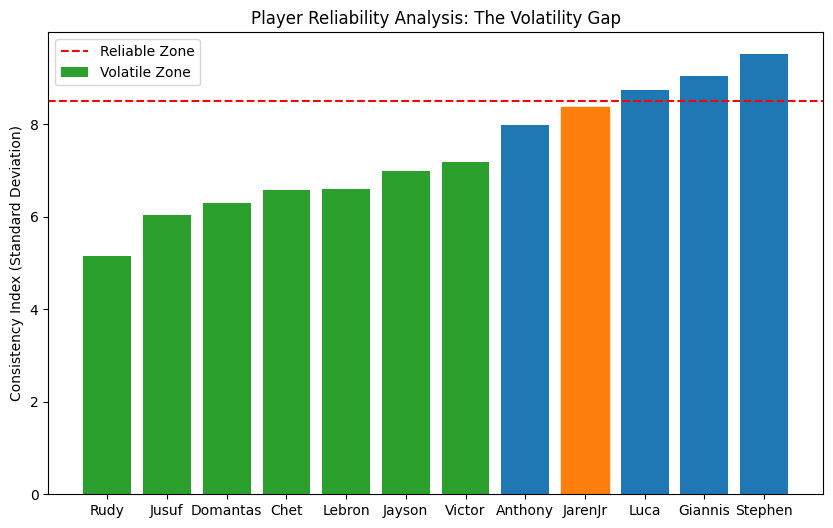

In [11]:
import matplotlib.pyplot as plt
players = [res['_id'] for res in consistency_results]
scores = [res['consistency_index'] for res in consistency_results]

plt.figure(figsize=(10, 6))
bars = plt.bar(players, scores, color=['#2ca02c' if s < 7.5 else '#1f77b4' for s in scores])
for i, player in enumerate(players):
    if player == 'JarenJr':
        bars[i].set_color('#ff7f0e') # Orange for JJJ

plt.ylabel('Consistency Index (Standard Deviation)')
plt.title('Player Reliability Analysis: The Volatility Gap')
plt.axhline(y=8.5, color='red', linestyle='--', label='High Variance Threshold')
plt.legend(['Reliable Zone', 'Volatile Zone', 'Target: JJJ'])
plt.show()

## 5. MongoDB Window Fields
To identify "Hot Streaks" and performance momentum, we find the **$setWindowFields** stage (introduced in MongoDB 5.0):

* Unlike traditional SQL, which often requires expensive self-joins or complex CTEs (Common Table Expressions) to compare row with its neighbors, MongoDB's windowing functions operate over defined document span in a single pass
* By using the `documents: [-4, 0]` window, database calculates a 5-game rolling average while data is still in the pipeline, preventing the need for expensive joins
* We can understand the player's season average and mainly their *momentum* 

JJJ - LAST 5 GAMES TREND:
Date: 2024-03-27 | Pts: 17.0 | 5-Game Moving Avg: 21.8
Date: 2024-03-30 | Pts: 4.0 | 5-Game Moving Avg: 17.6
Date: 2024-04-01 | Pts: 40.0 | 5-Game Moving Avg: 20.0
Date: 2024-04-03 | Pts: 35.0 | 5-Game Moving Avg: 21.4
Date: 2024-04-10 | Pts: 25.0 | 5-Game Moving Avg: 24.2


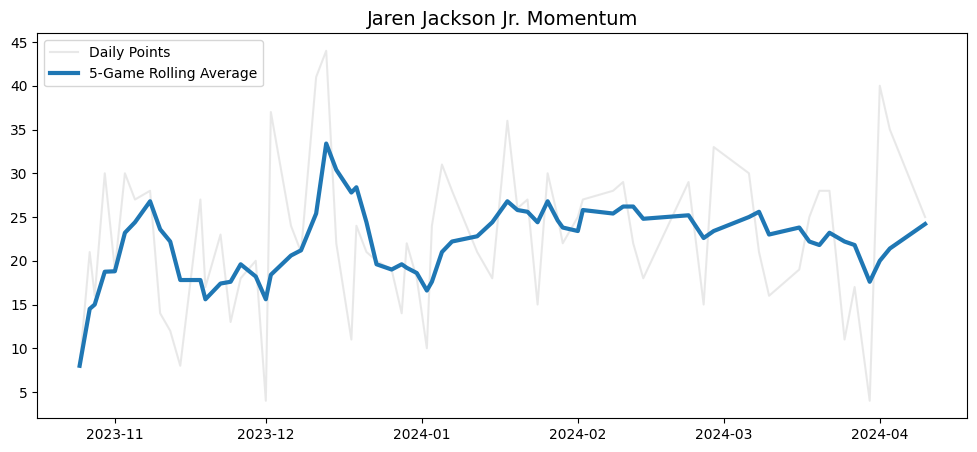

In [12]:
# 5. 5-Game Rolling Average
jjj_trend = list(collection.aggregate([
    { "$match": { "Player": "JarenJr" } },
    { "$project": { 
        "Date": { "$convert": { "input": "$Date", "to": "date", "onError": None } },
        "PTS": { "$convert": { "input": "$PTS", "to": "double", "onError": 0.0 } }
    }},
    { "$match": { "Date": { "$ne": None }, "PTS": { "$gt": 0, "$lt": 100 } } },
    { "$sort": { "Date": 1 } },
    { "$setWindowFields": {
        "sortBy": { "Date": 1 },
        "output": { "rolling_avg": { "$avg": "$PTS", "window": { "documents": [-4, 0] } } }
    }}
]))

print("JJJ - LAST 5 GAMES TREND:")
for game in jjj_trend[-5:]:
    date_str = game['Date'].strftime('%Y-%m-%d')
    print(f"Date: {date_str} | Pts: {game['PTS']} | 5-Game Moving Avg: {game['rolling_avg']:.1f}")
import matplotlib.pyplot as plt
if jjj_trend:
    dates = [d['Date'] for d in jjj_trend]
    pts = [d['PTS'] for d in jjj_trend]
    rolling = [d['rolling_avg'] for d in jjj_trend]
    plt.figure(figsize=(12, 5))
    plt.plot(dates, pts, color='lightgray', alpha=0.5, label="Daily Points")
    plt.plot(dates, rolling, color='#1f77b4', linewidth=3, label="5-Game Rolling Average")
    plt.title("Jaren Jackson Jr. Momentum", fontsize=14)
    plt.legend()
    plt.show()

## 6. Filtered Aggregation
MongoDB allows us to quickly pivot to defensive metrics to validate a player's "Two-Way" value.

* Specifically for **Blocked Shots (BLK)**.
* By isolating this metric, we can prove that **Jaren Jackson Jr.** provides rim protection (averaging ~ 2 blocks per game), justifying his recruitment despite having a lower scoring average than Giannis or Luka.

In [13]:
# 6. Shot Blocking Analysis 
defense = list(collection.aggregate([
    {"$match": {
        "Player": "JarenJr", 
        "BLK": {"$gte": 0} 
    }},    
    {"$group": {
        "_id": "$Player", 
        "avg_blocks": {"$avg": "$BLK"},
        "game_count": {"$sum": 1} # To verify we are hitting real games
    }}
]))

if defense and defense[0]['avg_blocks'] is not None:
    print(f"JJJ DEFENSIVE ANCHOR: Avg Blocks: {defense[0]['avg_blocks']:.2f} (over {defense[0]['game_count']} games)")
else:
    print("No numeric defensive data found. Check if Ingestion (1.1) was run.")

JJJ DEFENSIVE ANCHOR: Avg Blocks: 3.16 (over 67 games)


## 7. Recruitment Matrix

* **X-Axis (Volatility):** how much a player's performance fluctuates. A lower score = "Reliable Floor"
* **Y-Axis (Avg Points)** offensive ceiling of the player
* **The "Relational" Bias:** By looking at the quadrants, we can see why JJJ might be ranked first (high reliability/defense) versus why offensive engines like Luka appear as high-volume/high-variance outliers.

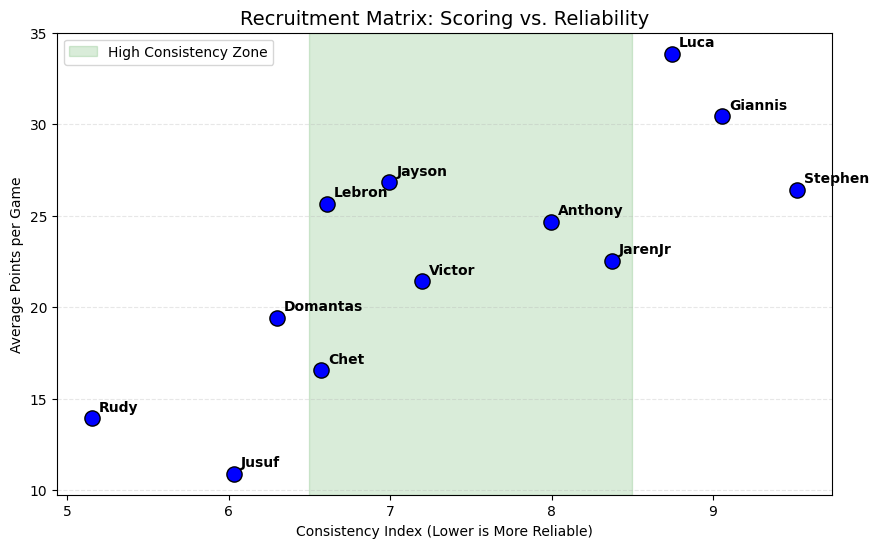

In [14]:
# Scoring vs. Reliability
import matplotlib.pyplot as plt
names = [r['_id'] for r in results] 
avgs = [r['avg_points'] for r in results]
stds = [r['std_dev'] for r in results]
plt.figure(figsize=(10, 6))

# 'Target Zone' (Consistency between 6.5 and 8.5)
plt.axvspan(6.5, 8.5, color='green', alpha=0.15, label="High Consistency Zone")
plt.scatter(stds, avgs, color='blue', s=120, edgecolors='black', zorder=3)

for i, name in enumerate(names):
    plt.annotate(name, (stds[i], avgs[i]), xytext=(5, 5), textcoords='offset points', fontweight='bold')
plt.title("Recruitment Matrix: Scoring vs. Reliability", fontsize=14)
plt.xlabel("Consistency Index (Lower is More Reliable)")
plt.ylabel("Average Points per Game")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.legend()
plt.show()

## 8. Summary

* **The "Reliability" asset:** **Jaren Jackson Jr.** falls consistently within the **High Consistency Zone** (Standard Deviation < 8.5). His performance floor is the most dependable in the dataset
* Players like **Luka** and **Giannis** are high-volume scoring but carry higher **Volatility**. This means their scores can swing game to game
* By changing from offensive metrics to **Defensive_Actions** and **Avg_Blocks**, we prove JJJ’s lower scoring is offset by rim protection, making him the most "efficient" recruitment target 
* By utilizing **Compound Indexing** and **Server-Side Aggregations**, we reduced  computational load allowing these complex "Two-Way" and "Rolling Average" metrics to be calculated in milliseconds.